    HOUR 1: MACHINE LEARNING FUNDAMENTALS (60 mins)
    
    1.1 What is Machine Learning?
    
    Definition

    Machine Learning is a subset of Artificial Intelligence where computers learn patterns from data without being explicitly programmed for every scenario. The system improves automatically through experience.
    
    Indian Analogy: The Chai Wala Example ☕
    
    Think of a chai wala near Mumbai Central station:
    
    Day 1-10 (Learning Phase):

        Notices office-goers (9 AM) prefer cutting chai (small, strong)
        College students (afternoon) want special chai with extra sugar
        Evening crowd prefers adrak chai (ginger tea)

    Day 11 onwards (Prediction Phase):

        Sees a person in formal clothes at 9 AM → Prepares cutting chai
        Group of youngsters at 3 PM → Prepares special chai

    Nobody explicitly taught him these rules — he learned from observing patterns. This is Machine Learning!The Learning Process
    
    ┌─────────────┐    ┌─────────────┐    ┌─────────────┐
    │    DATA     │ →  │   MODEL     │ →  │ PREDICTIONS │
    │  (Examples) │    │  (Patterns) │    │   (Output)  │
    └─────────────┘    └─────────────┘    └─────────────┘
        ↓                  ↓                  ↓
    Past chai orders   Rules learned    New customer's chai
    
    1.2 Three Types of Machine Learning

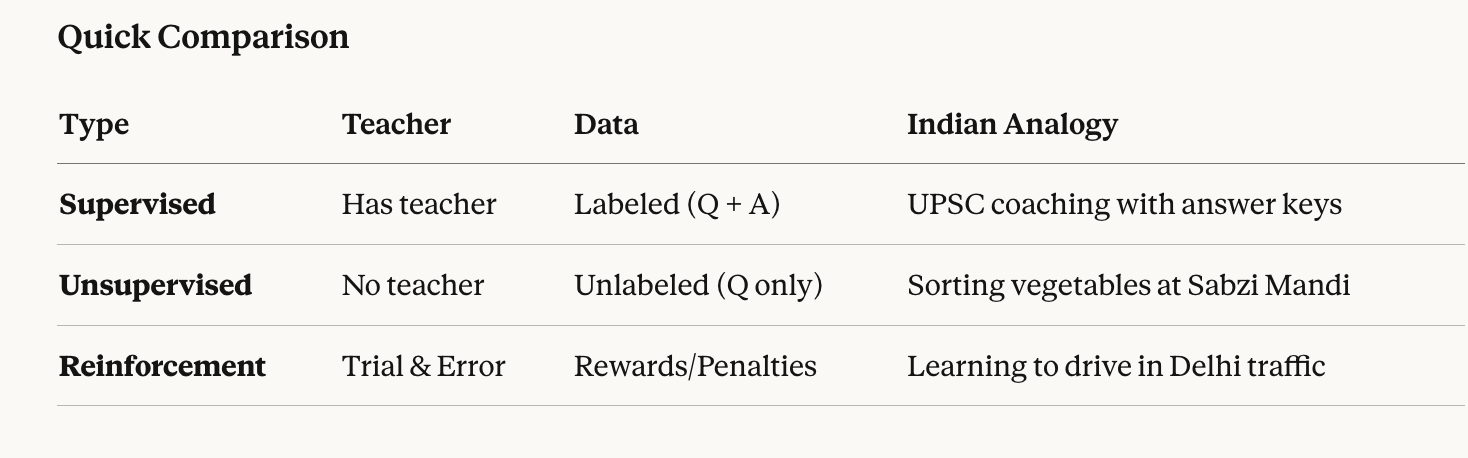

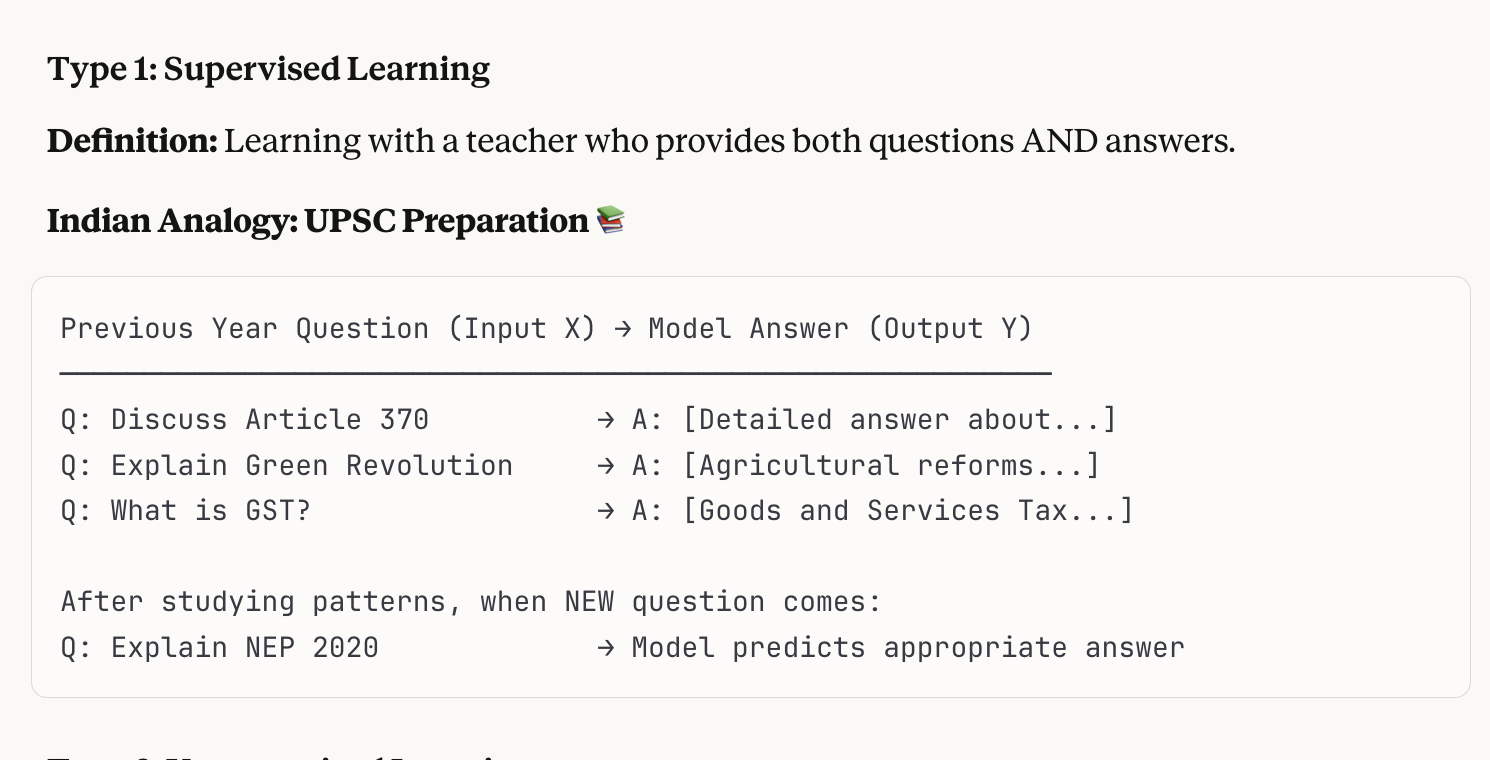

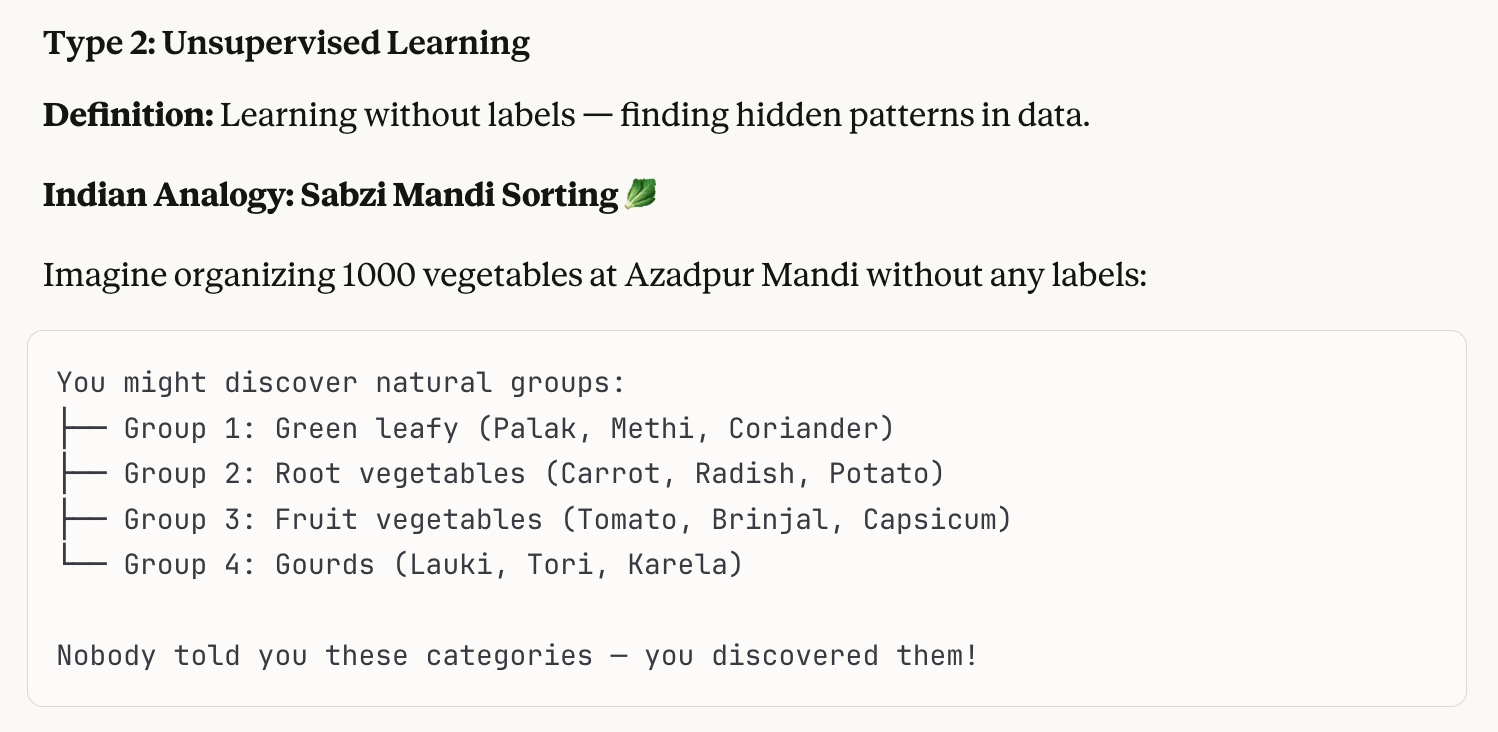

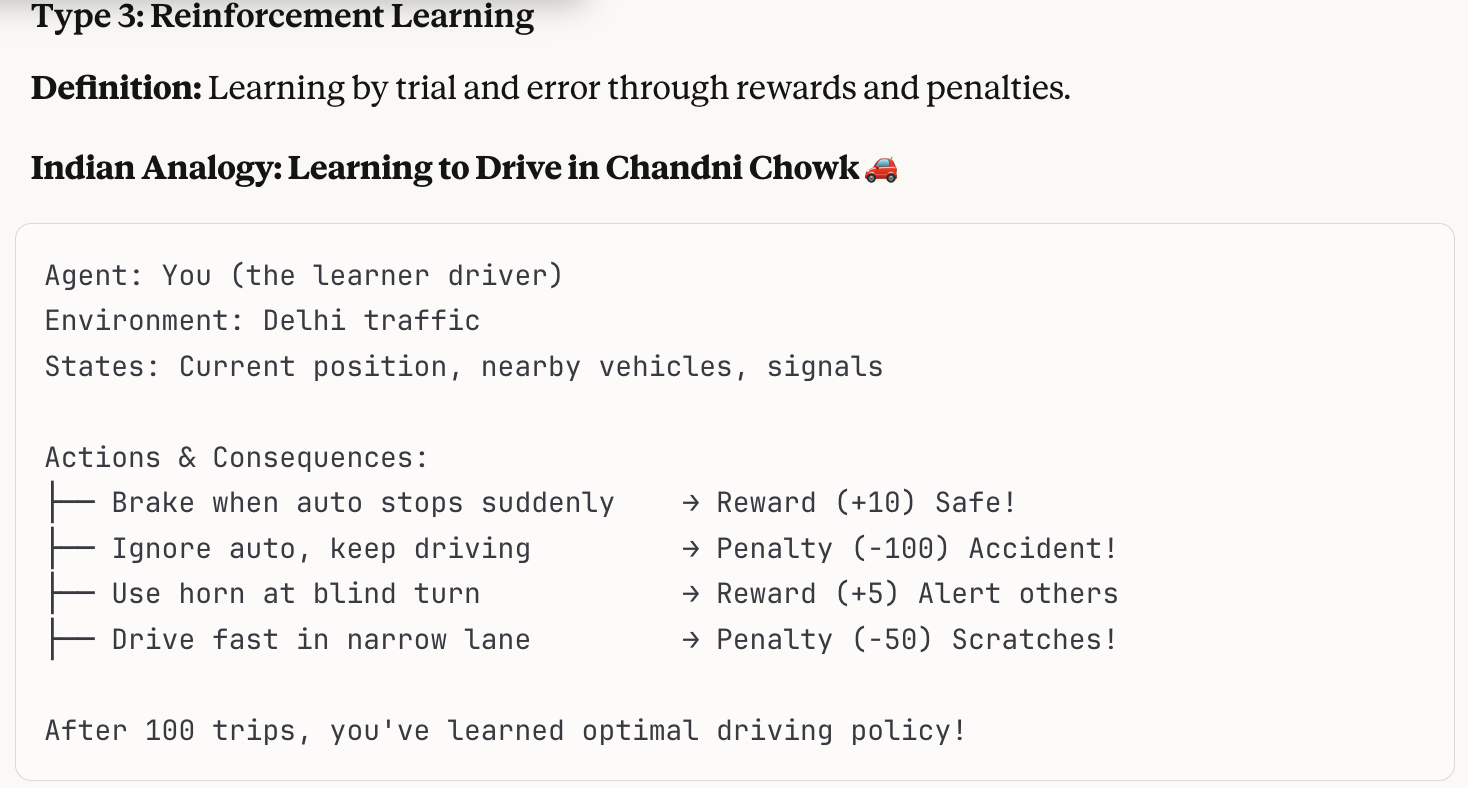

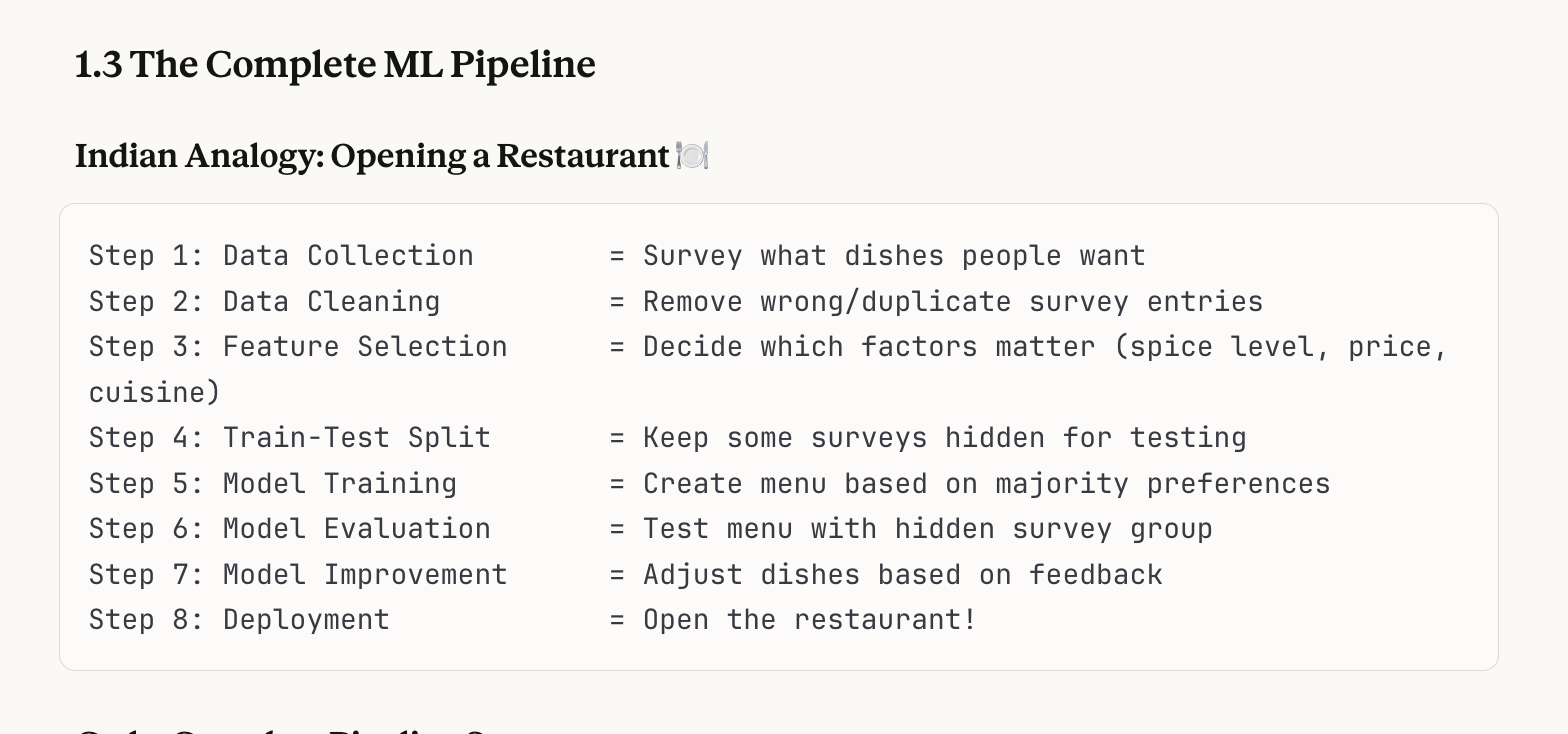

In [ ]:

# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error

# Step 2: Load Data
data = pd.read_csv('your_data.csv')

# Step 3: Explore Data
print(data.head())
print(data.info())
print(data.describe())

# Step 4: Handle Missing Values
data = data.dropna()  # or data.fillna(data.mean())

# Step 5: Feature Selection
X = data[['feature1', 'feature2', 'feature3']]  # Input features
y = data['target']                               # Output variable

# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7: Feature Scaling (if needed)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Train Model
model = YourModel()
model.fit(X_train_scaled, y_train)

# Step 9: Predict
y_pred = model.predict(X_test_scaled)

# Step 10: Evaluate
score = accuracy_score(y_test, y_pred)  # For classification
# or
mse = mean_squared_error(y_test, y_pred)  # For regression

# Step 11: Cross-Validation
cv_scores = cross_val_score(model, X, y, cv=5)
print(f"CV Score: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

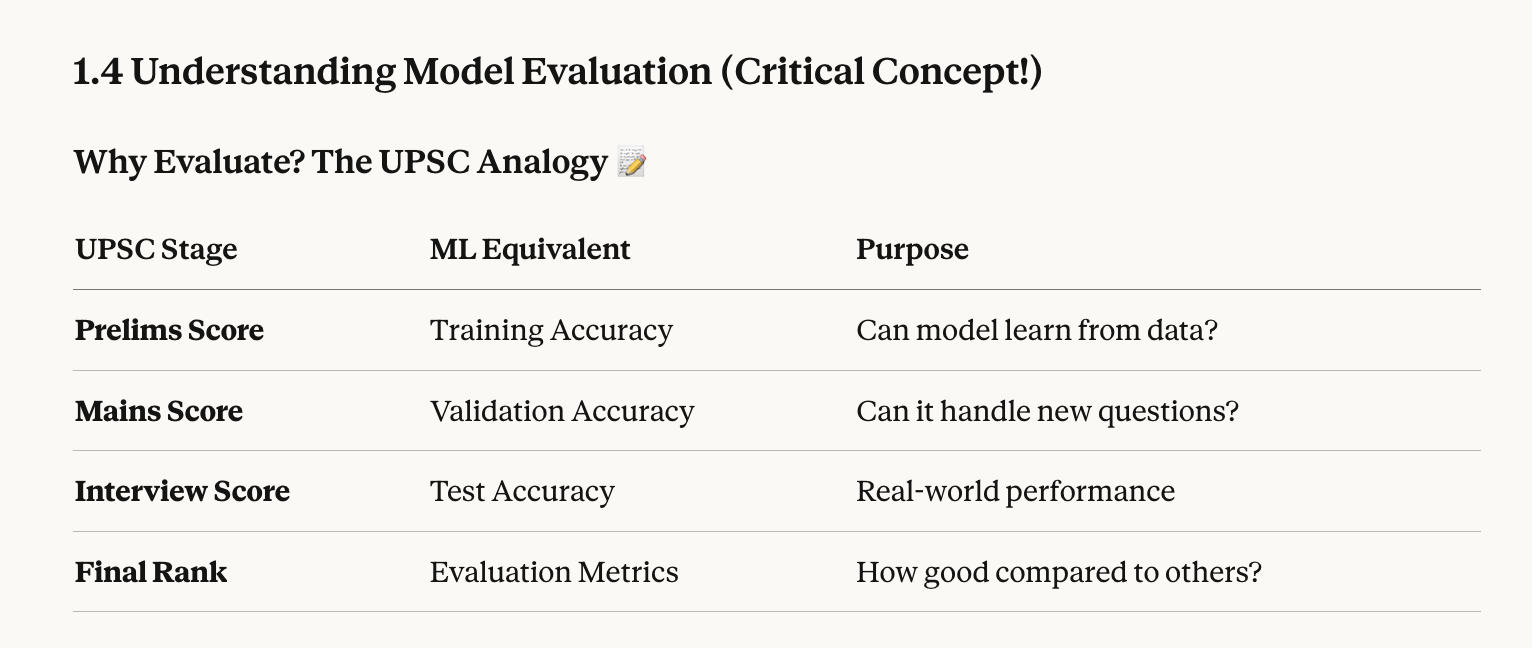

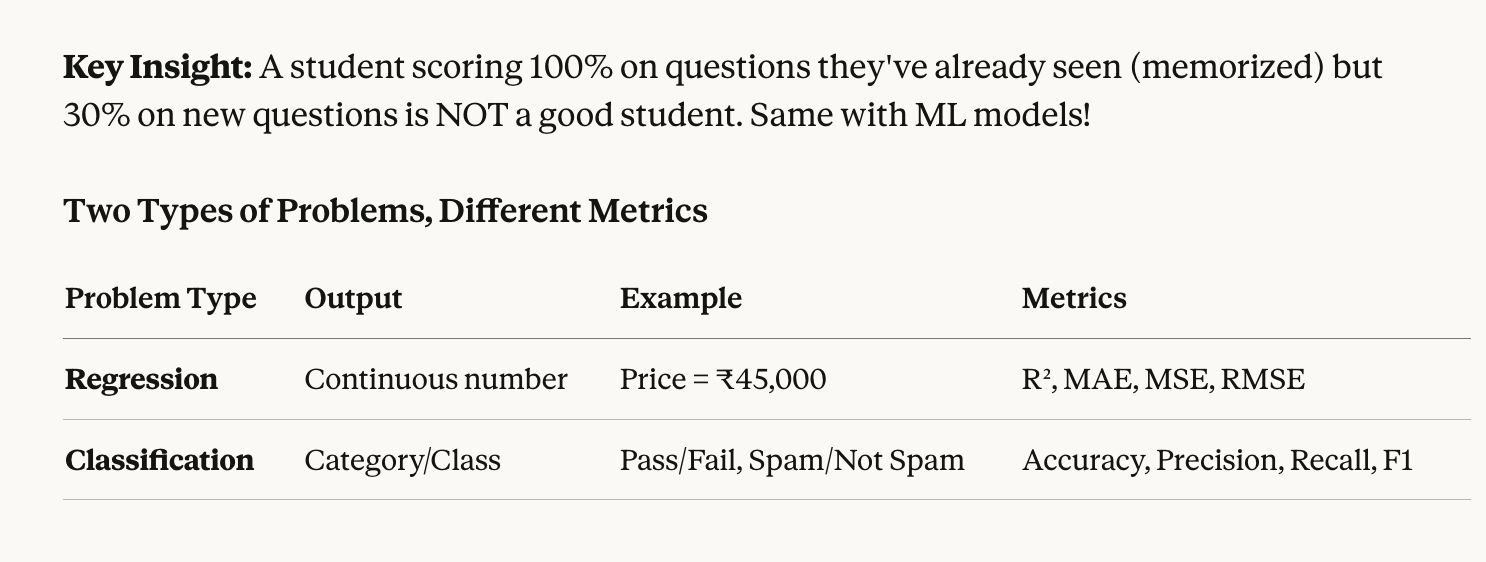

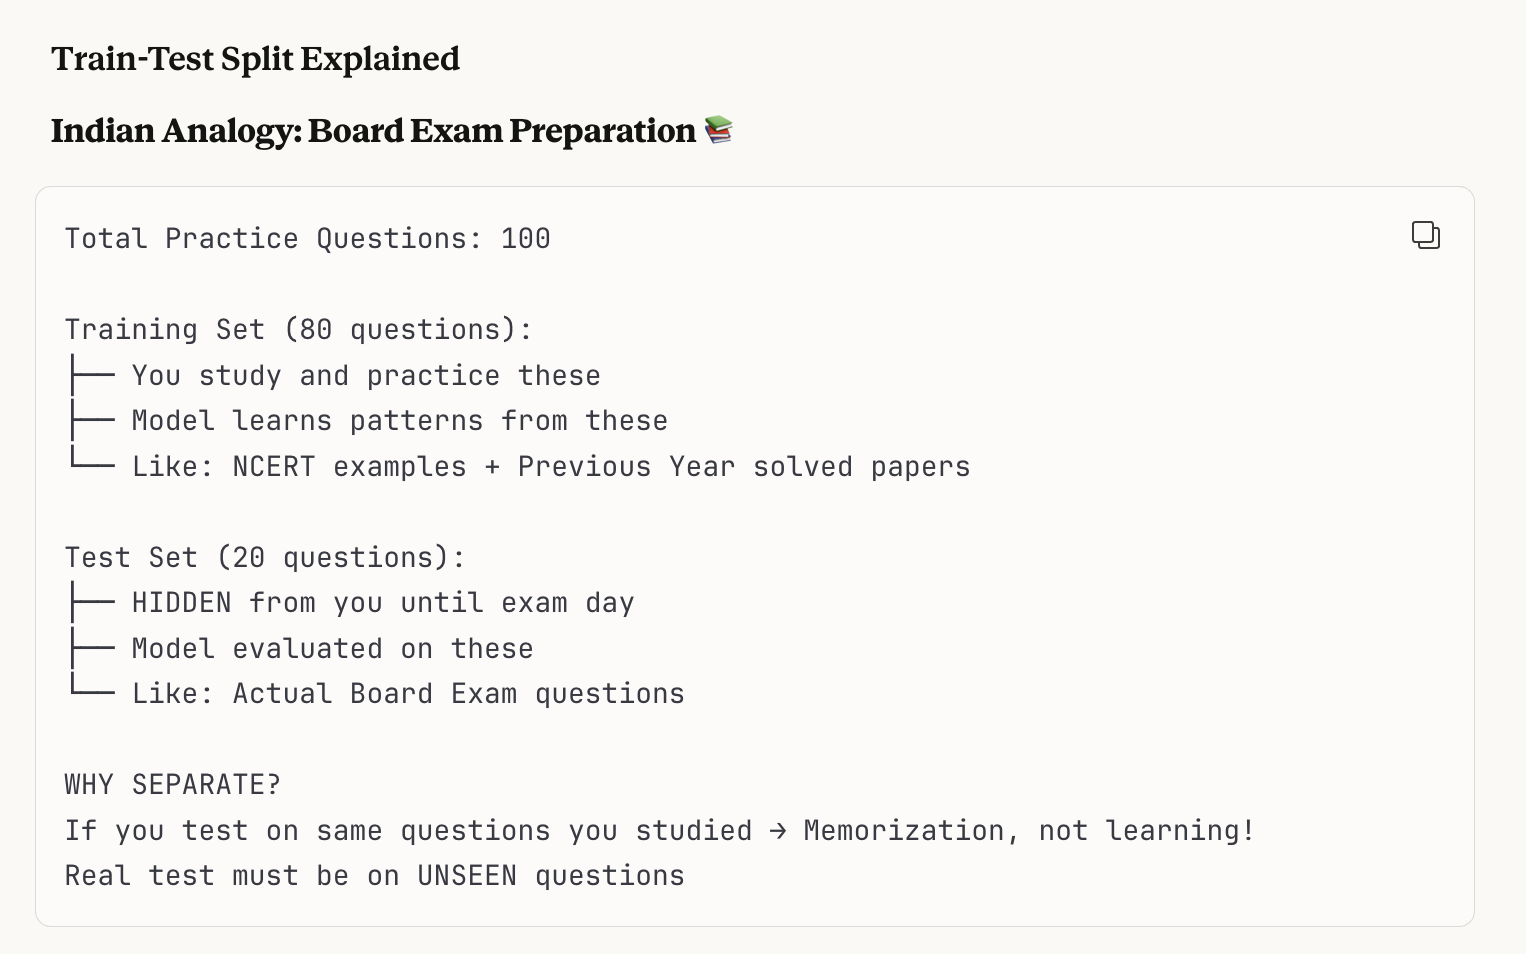

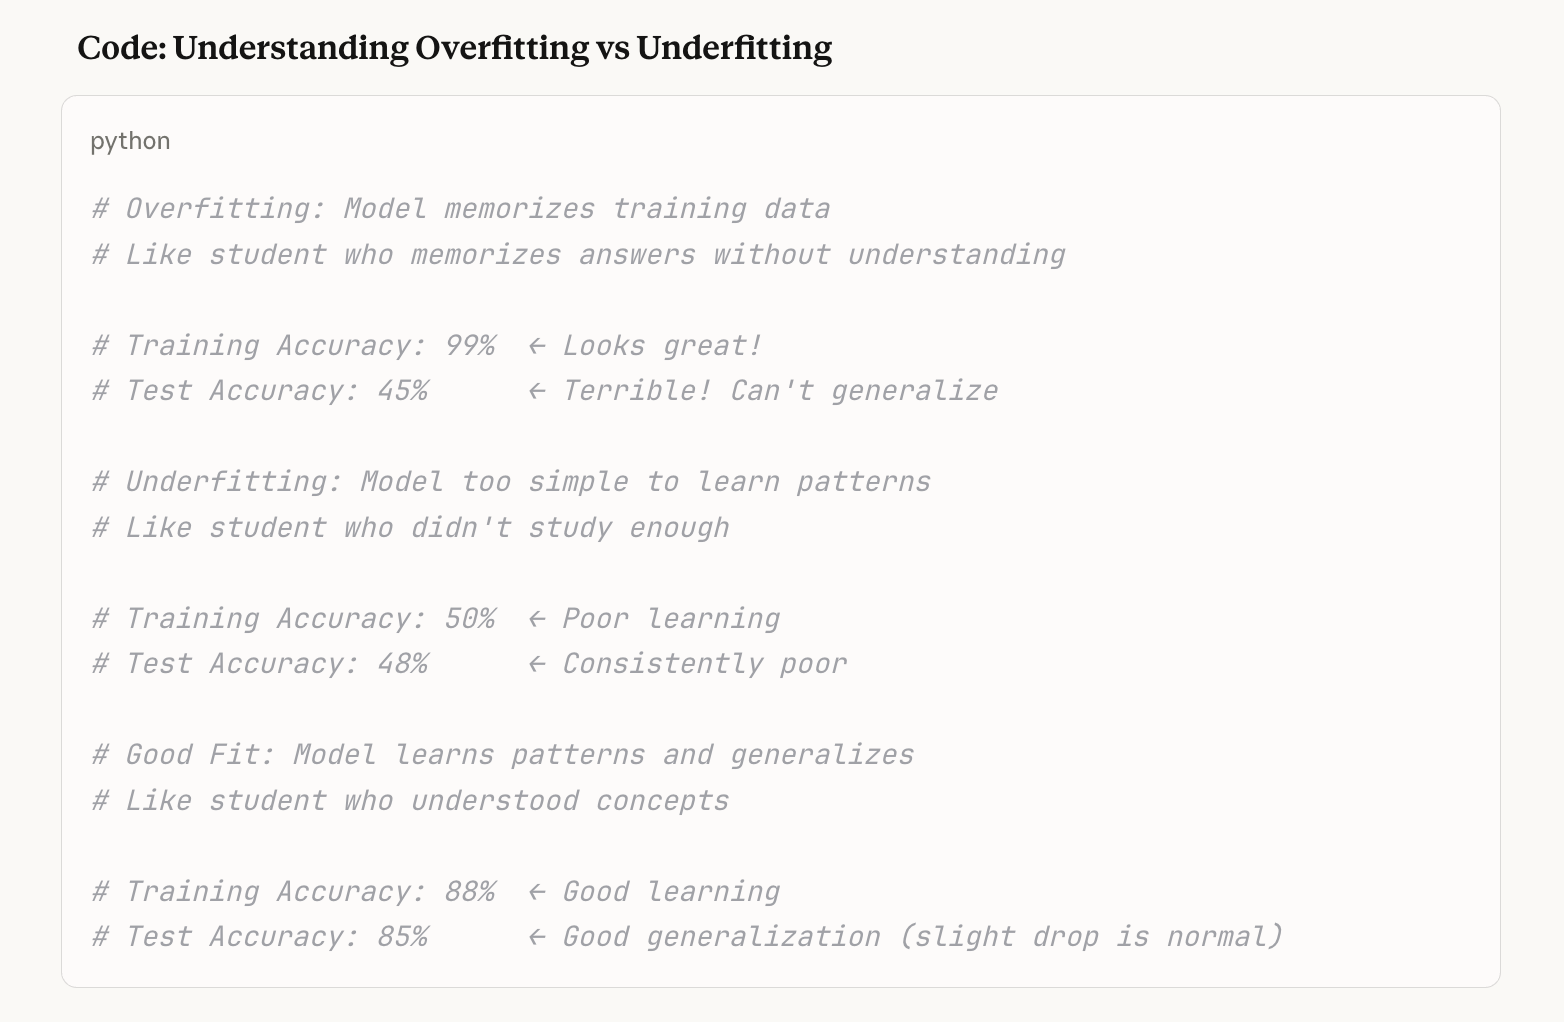

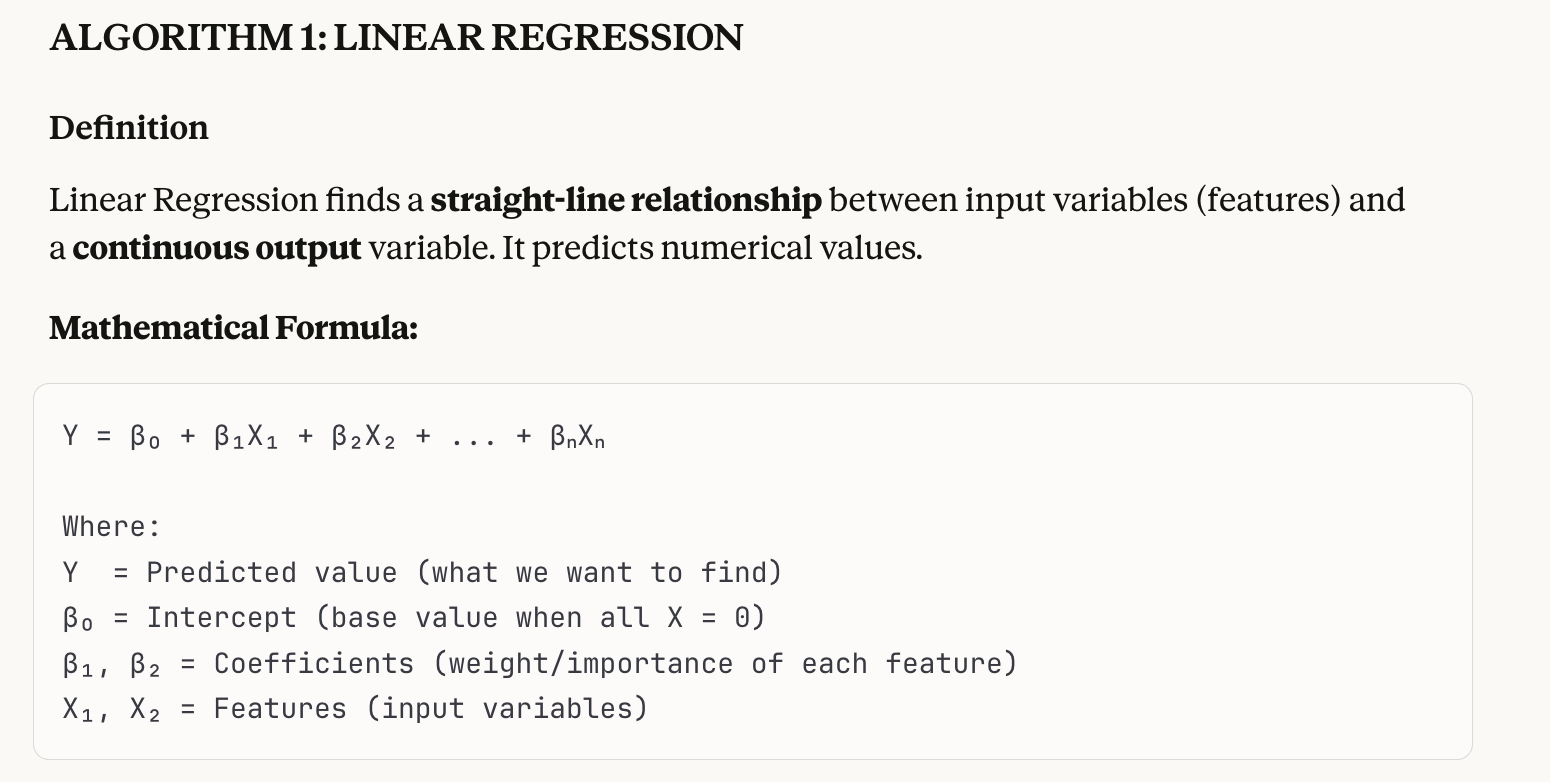

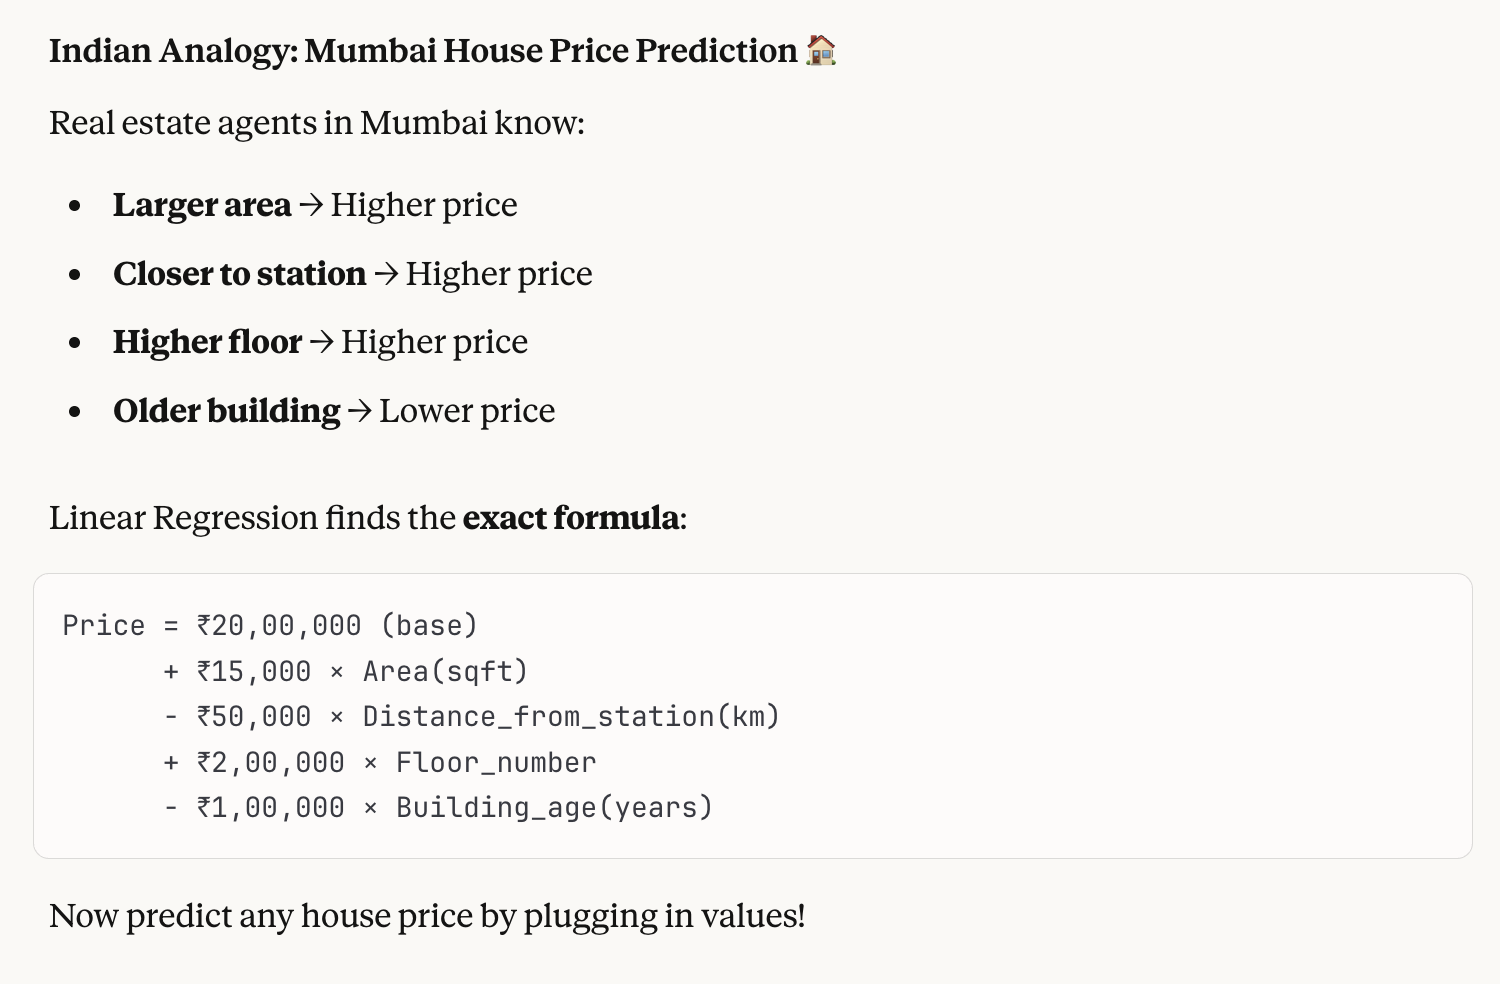

=== Dataset Overview ===
   area_sqft  distance_station_km  floor  building_age_years  price_lakhs
0       1626             7.863762     19                  12    89.660708
1       1959             9.425240      2                  28    81.518100
2       1360             9.000860     12                  29    56.424813
3       1794             6.180050      6                  14    83.503770
4       1630             9.257805      4                  21    65.599037
5       1595             1.340679     11                   6   101.539532
6       2224             2.361837     17                   3   125.174917
7       1544             0.929659      6                  28    79.058025
8       2138             3.590638      5                   9   111.640341
9        621             4.192434      2                   5    42.172724

Dataset Shape: (100, 5)

Statistics:
         area_sqft  distance_station_km       floor  building_age_years  \
count   100.000000           100.000000  100.000

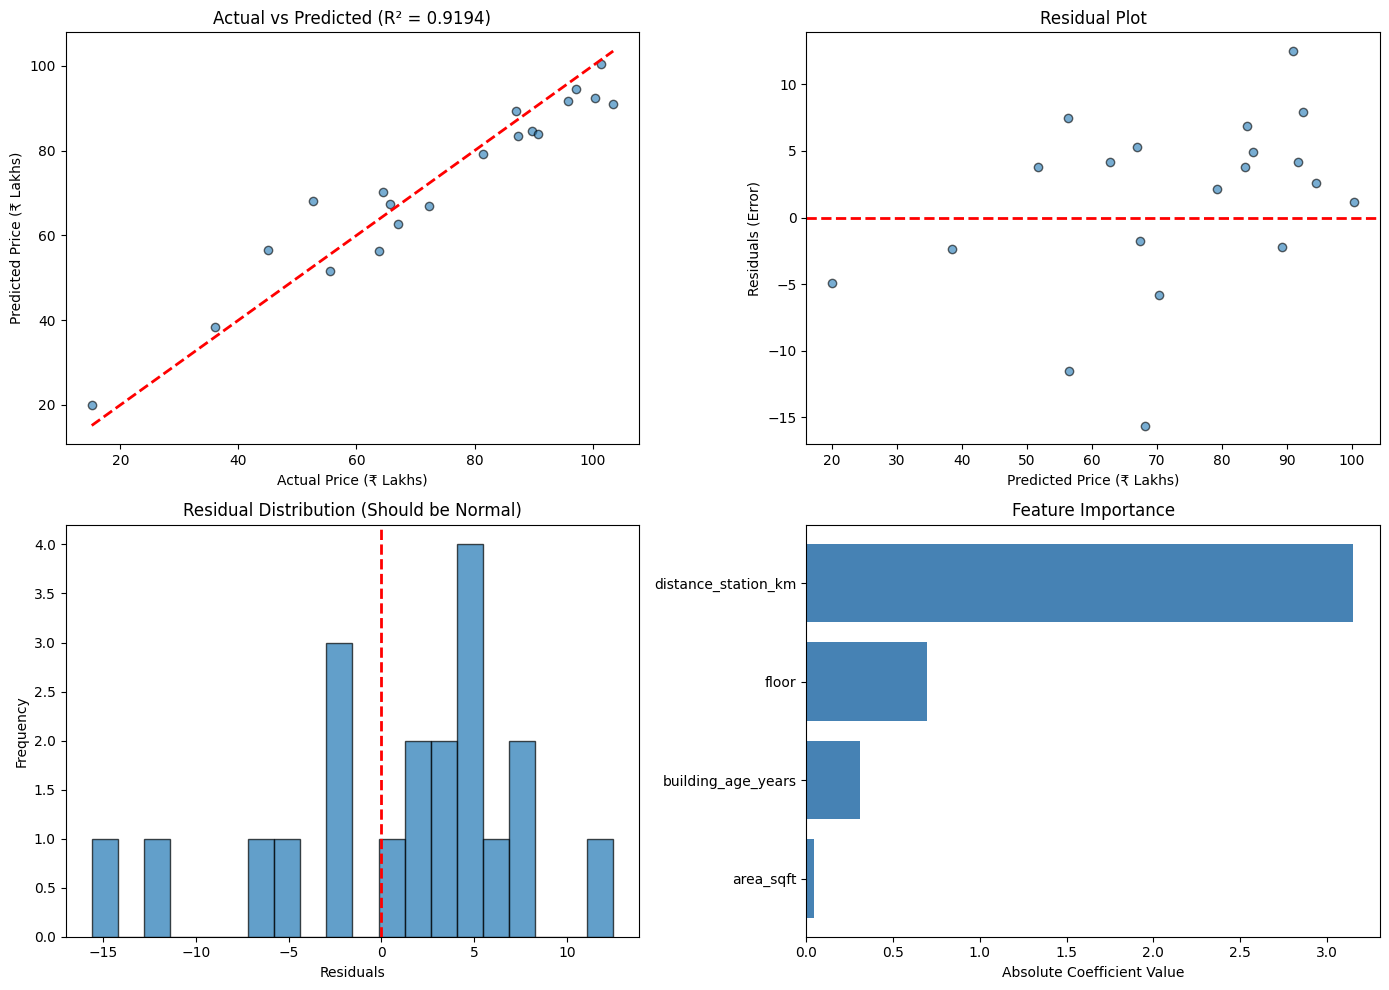


=== PREDICTION FOR NEW HOUSE ===

New House Details:
  Area: 1200 sqft
  Distance from Station: 2.5 km
  Floor: 8th
  Building Age: 5 years

🏠 Predicted Price: ₹76.31 Lakhs


In [1]:
# ============================================================
# LINEAR REGRESSION - COMPLETE IMPLEMENTATION WITH EVALUATION
# ============================================================

# Step 1: Import Libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Create Dataset - Mumbai House Prices
np.random.seed(42)
n_samples = 100

data = {
    'area_sqft': np.random.randint(500, 2500, n_samples),
    'distance_station_km': np.random.uniform(0.5, 10, n_samples),
    'floor': np.random.randint(1, 20, n_samples),
    'building_age_years': np.random.randint(1, 30, n_samples),
}
df = pd.DataFrame(data)

# Create target variable (price) with some relationship + noise
df['price_lakhs'] = (
    20 +                                    # Base price
    0.05 * df['area_sqft'] +               # ₹5000 per sqft
    -3 * df['distance_station_km'] +       # -₹3L per km from station
    0.5 * df['floor'] +                    # ₹50k per floor
    -0.3 * df['building_age_years'] +      # -₹30k per year old
    np.random.normal(0, 5, n_samples)      # Random noise
)

print("=== Dataset Overview ===")
print(df.head(10))
print(f"\nDataset Shape: {df.shape}")
print(f"\nStatistics:\n{df.describe()}")

# Step 3: Define Features (X) and Target (y)
X = df[['area_sqft', 'distance_station_km', 'floor', 'building_age_years']]
y = df['price_lakhs']

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42     # For reproducibility
)

print(f"\n=== Data Split ===")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Step 5: Create and Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 6: View Model Parameters (What model learned)
print(f"\n=== Model Parameters (What the model learned) ===")
print(f"Intercept (Base Price): ₹{model.intercept_:.2f} Lakhs")
print(f"\nCoefficients (Feature Importance):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

# Interpretation
print(f"\n=== Interpretation ===")
print(f"• For every 1 sqft increase → Price increases by ₹{model.coef_[0]*100:.0f}")
print(f"• For every 1 km farther from station → Price decreases by ₹{abs(model.coef_[1]):.2f} Lakhs")
print(f"• For every 1 floor higher → Price increases by ₹{model.coef_[2]:.2f} Lakhs")
print(f"• For every 1 year older building → Price decreases by ₹{abs(model.coef_[3]):.2f} Lakhs")

# Step 7: Make Predictions
y_train_pred = model.predict(X_train)  # Predictions on training data
y_test_pred = model.predict(X_test)    # Predictions on test data

# Step 8: EVALUATION METRICS
print(f"\n{'='*60}")
print(f"=== MODEL EVALUATION ===")
print(f"{'='*60}")

# --- Training Set Metrics ---
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)

print(f"\n--- Training Set Performance ---")
print(f"R² Score: {train_r2:.4f} ({train_r2*100:.2f}% variance explained)")
print(f"MAE: ₹{train_mae:.2f} Lakhs (Average error)")
print(f"MSE: {train_mse:.2f}")
print(f"RMSE: ₹{train_rmse:.2f} Lakhs (Typical error)")

# --- Test Set Metrics ---
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

print(f"\n--- Test Set Performance ---")
print(f"R² Score: {test_r2:.4f} ({test_r2*100:.2f}% variance explained)")
print(f"MAE: ₹{test_mae:.2f} Lakhs (Average error)")
print(f"MSE: {test_mse:.2f}")
print(f"RMSE: ₹{test_rmse:.2f} Lakhs (Typical error)")

# --- Compare Train vs Test (Check for Overfitting) ---
print(f"\n--- Overfitting Check ---")
r2_diff = train_r2 - test_r2
print(f"Train R² - Test R² = {r2_diff:.4f}")
if r2_diff > 0.1:
    print("⚠️ WARNING: Model might be OVERFITTING (train >> test)")
elif test_r2 < 0.5:
    print("⚠️ WARNING: Model might be UNDERFITTING (both scores low)")
else:
    print("✅ Model looks GOOD! (train ≈ test)")

# Step 9: CROSS-VALIDATION
print(f"\n{'='*60}")
print(f"=== CROSS-VALIDATION (5-Fold) ===")
print(f"{'='*60}")

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='r2')

print(f"\nFold-wise R² Scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")
print(f"\nFinal Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Interpretation
if cv_scores.std() > 0.1:
    print("⚠️ High variance across folds - model unstable")
else:
    print("✅ Consistent performance across folds")

# Step 10: VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='black')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Price (₹ Lakhs)')
axes[0, 0].set_ylabel('Predicted Price (₹ Lakhs)')
axes[0, 0].set_title(f'Actual vs Predicted (R² = {test_r2:.4f})')

# Plot 2: Residuals (Errors)
residuals = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.6, edgecolors='black')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price (₹ Lakhs)')
axes[0, 1].set_ylabel('Residuals (Error)')
axes[0, 1].set_title('Residual Plot')

# Plot 3: Residual Distribution
axes[1, 0].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Residual Distribution (Should be Normal)')

# Plot 4: Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': np.abs(model.coef_)
}).sort_values('Coefficient', ascending=True)
axes[1, 1].barh(feature_importance['Feature'], feature_importance['Coefficient'], color='steelblue')
axes[1, 1].set_xlabel('Absolute Coefficient Value')
axes[1, 1].set_title('Feature Importance')

plt.tight_layout()
plt.savefig('linear_regression_evaluation.png', dpi=150)
plt.show()

# Step 11: PREDICT FOR NEW DATA
print(f"\n{'='*60}")
print(f"=== PREDICTION FOR NEW HOUSE ===")
print(f"{'='*60}")

new_house = pd.DataFrame({
    'area_sqft': [1200],
    'distance_station_km': [2.5],
    'floor': [8],
    'building_age_years': [5]
})

predicted_price = model.predict(new_house)[0]
print(f"\nNew House Details:")
print(f"  Area: 1200 sqft")
print(f"  Distance from Station: 2.5 km")
print(f"  Floor: 8th")
print(f"  Building Age: 5 years")
print(f"\n🏠 Predicted Price: ₹{predicted_price:.2f} Lakhs")

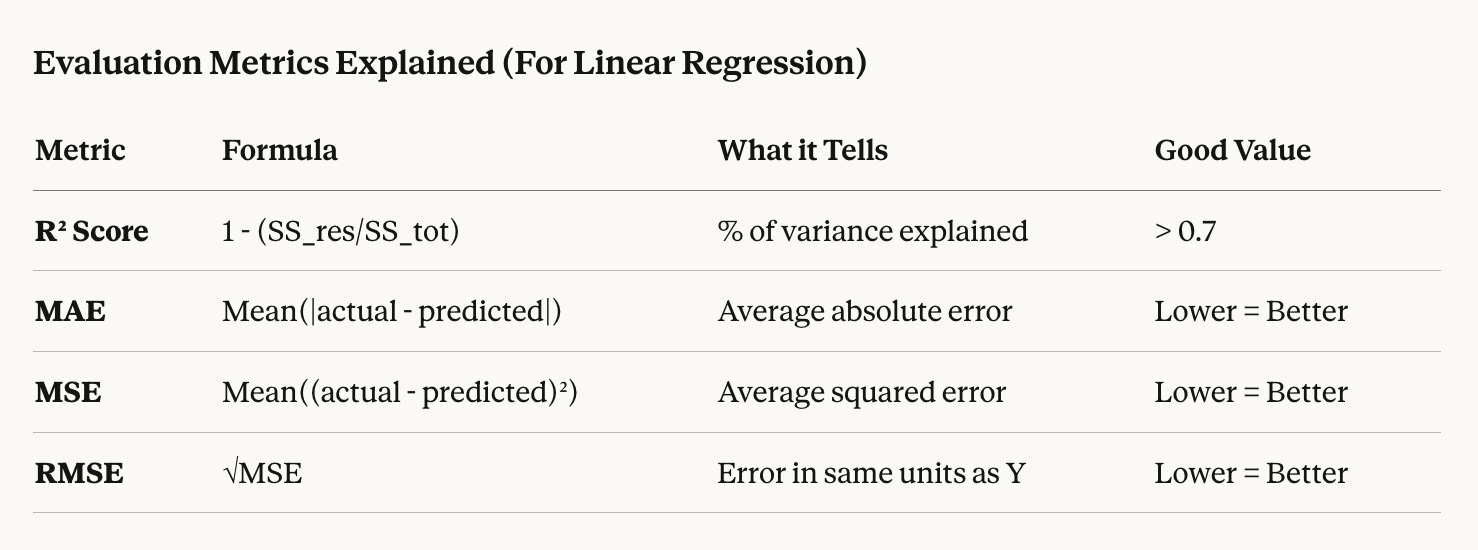

In [3]:
# ============================================================
# EXAMPLE 1: IPL FINAL SCORE PREDICTION
# ============================================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Create IPL Match Data
np.random.seed(42)
n_matches = 150

ipl_data = {
    'powerplay_score': np.random.randint(30, 70, n_matches),
    'powerplay_wickets': np.random.randint(0, 4, n_matches),
    'run_rate_7_to_15': np.random.uniform(6, 12, n_matches),
    'wickets_in_hand_at_15': np.random.randint(4, 10, n_matches),
}
df = pd.DataFrame(ipl_data)

# Target: Final Score
df['final_score'] = (
    df['powerplay_score'] * 1.2 +
    df['run_rate_7_to_15'] * 8 +
    df['wickets_in_hand_at_15'] * 5 -
    df['powerplay_wickets'] * 8 +
    np.random.normal(0, 10, n_matches)
).astype(int)

print("=== IPL Match Data ===")
print(df.head())

# Split Data
X = df[['powerplay_score', 'powerplay_wickets', 'run_rate_7_to_15', 'wickets_in_hand_at_15']]
y = df['final_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# === EVALUATION ===
print(f"\n=== IPL SCORE PREDICTION EVALUATION ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} runs")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} runs")

# Cross-Validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"\nCross-Validation R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Interpretation
print(f"\n=== INTERPRETATION ===")
print(f"Model Coefficients:")
for feat, coef in zip(X.columns, model.coef_):
    print(f"  {feat}: {coef:.2f}")

# Real Prediction
print(f"\n=== LIVE MATCH PREDICTION ===")
match_situation = {
    'powerplay_score': 52,
    'powerplay_wickets': 1,
    'run_rate_7_to_15': 9.5,
    'wickets_in_hand_at_15': 8
}
pred_score = model.predict(pd.DataFrame([match_situation]))[0]
print(f"Powerplay: 52/1, Run Rate (7-15): 9.5, Wickets in hand: 8")
print(f"🏏 Predicted Final Score: {pred_score:.0f} runs")

=== IPL Match Data ===
   powerplay_score  powerplay_wickets  run_rate_7_to_15  \
0               68                  1         11.137946   
1               58                  0          8.427049   
2               44                  0         11.326621   
3               37                  0         11.105571   
4               50                  2         11.613810   

   wickets_in_hand_at_15  final_score  
0                      7          190  
1                      5          159  
2                      5          171  
3                      6          177  
4                      5          170  

=== IPL SCORE PREDICTION EVALUATION ===
R² Score: 0.8570
MAE: 8.60 runs
RMSE: 10.42 runs

Cross-Validation R²: 0.8338 ± 0.0262

=== INTERPRETATION ===
Model Coefficients:
  powerplay_score: 1.09
  powerplay_wickets: -7.45
  run_rate_7_to_15: 8.75
  wickets_in_hand_at_15: 4.89

=== LIVE MATCH PREDICTION ===
Powerplay: 52/1, Run Rate (7-15): 9.5, Wickets in hand: 8
🏏 Predicted Fin

In [4]:
# ============================================================
# EXAMPLE 2: MONTHLY PETROL EXPENSE PREDICTION
# ============================================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Create Data
np.random.seed(42)
n_months = 100

petrol_data = {
    'km_driven': np.random.randint(300, 1500, n_months),
    'petrol_price_per_litre': np.random.uniform(95, 110, n_months),
    'traffic_index': np.random.randint(1, 10, n_months),  # 1=smooth, 10=jam
    'ac_usage_percent': np.random.randint(0, 100, n_months),
}
df = pd.DataFrame(petrol_data)

# Mileage decreases with traffic and AC usage
base_mileage = 15  # km per litre
effective_mileage = base_mileage - df['traffic_index'] * 0.5 - df['ac_usage_percent'] * 0.03
litres_consumed = df['km_driven'] / effective_mileage
df['expense_rs'] = (litres_consumed * df['petrol_price_per_litre'] + np.random.normal(0, 100, n_months)).astype(int)

print("=== Petrol Expense Data ===")
print(df.head())

# Split Data
X = df[['km_driven', 'petrol_price_per_litre', 'traffic_index', 'ac_usage_percent']]
y = df['expense_rs']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# === EVALUATION ===
print(f"\n=== PETROL EXPENSE PREDICTION EVALUATION ===")
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f} ({r2*100:.1f}% variance explained)")
print(f"MAE: ₹{mae:.2f} (Average prediction error)")
print(f"RMSE: ₹{rmse:.2f} (Typical error)")

# Cross-Validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"\nCross-Validation R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"MAPE: {mape:.2f}%")
if mape < 10:
    print("✅ Excellent! Predictions within 10% of actual")
elif mape < 20:
    print("⚠️ Good, but room for improvement")
else:
    print("❌ High error - model needs improvement")

# Prediction
print(f"\n=== PREDICT NEXT MONTH EXPENSE ===")
next_month = {
    'km_driven': 800,
    'petrol_price_per_litre': 105,
    'traffic_index': 7,
    'ac_usage_percent': 60
}
pred_expense = model.predict(pd.DataFrame([next_month]))[0]
print(f"Expected: 800km, Petrol ₹105/L, High traffic, 60% AC")
print(f"⛽ Predicted Expense: ₹{pred_expense:.0f}")

=== Petrol Expense Data ===
   km_driven  petrol_price_per_litre  traffic_index  ac_usage_percent  \
0       1426              104.349472              9                32   
1       1160               99.963470              2                 8   
2       1430               95.953375              7                42   
3       1395               99.664735              3                47   
4       1344               99.877750              7                38   

   expense_rs  
0       15642  
1        8504  
2       13307  
3       11493  
4       12632  

=== PETROL EXPENSE PREDICTION EVALUATION ===
R² Score: 0.9849 (98.5% variance explained)
MAE: ₹359.83 (Average prediction error)
RMSE: ₹455.22 (Typical error)

Cross-Validation R²: 0.9725 ± 0.0042
MAPE: 4.80%
✅ Excellent! Predictions within 10% of actual

=== PREDICT NEXT MONTH EXPENSE ===
Expected: 800km, Petrol ₹105/L, High traffic, 60% AC
⛽ Predicted Expense: ₹8988


In [6]:
# ============================================================
# EXAMPLE 3: EMPLOYEE SALARY PREDICTION (IT Companies)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Create Data
np.random.seed(42)
n_employees = 200

salary_data = {
    'years_experience': np.random.uniform(0, 15, n_employees),
    'education_level': np.random.choice([1, 2, 3], n_employees),  # 1=Bachelor, 2=Master, 3=PhD
    'certifications': np.random.randint(0, 6, n_employees),
    'company_tier': np.random.choice([1, 2, 3], n_employees),  # 1=Startup, 2=MNC, 3=FAANG
}
df = pd.DataFrame(salary_data)

# Salary Formula
df['salary_lpa'] = (
    3 +  # Base salary
    df['years_experience'] * 1.5 +
    df['education_level'] * 2 +
    df['certifications'] * 0.5 +
    df['company_tier'] * 5 +
    np.random.normal(0, 2, n_employees)
)
df['salary_lpa'] = df['salary_lpa'].clip(lower=3)  # Minimum 3 LPA

print("=== IT Employee Salary Data ===")
print(df.head(10))
print(f"\nSalary Range: ₹{df['salary_lpa'].min():.1f} LPA to ₹{df['salary_lpa'].max():.1f} LPA")

# Split Data
X = df[['years_experience', 'education_level', 'certifications', 'company_tier']]
y = df['salary_lpa']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# === COMPREHENSIVE EVALUATION ===
print(f"\n{'='*60}")
print(f"=== SALARY PREDICTION MODEL EVALUATION ===")
print(f"{'='*60}")

# Training Metrics
print(f"\n--- Training Set ---")
print(f"R² Score: {r2_score(y_train, y_train_pred):.4f}")
print(f"MAE: ₹{mean_absolute_error(y_train, y_train_pred):.2f} LPA")
print(f"RMSE: ₹{np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f} LPA")

# Test Metrics
print(f"\n--- Test Set ---")
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"R² Score: {test_r2:.4f}")
print(f"MAE: ₹{test_mae:.2f} LPA")
print(f"RMSE: ₹{test_rmse:.2f} LPA")

# Cross-Validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"\n--- Cross-Validation (5-Fold) ---")
print(f"R² Scores: {np.round(cv_scores, 4)}")
print(f"Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Model Coefficients
print(f"\n--- Model Interpretation ---")
print(f"Base Salary (Intercept): ₹{model.intercept_:.2f} LPA")
print(f"\nSalary Increase Per Unit:")
for feat, coef in zip(X.columns, model.coef_):
    print(f"  {feat}: ₹{coef:.2f} LPA")

# Predictions for Different Profiles
print(f"\n--- Sample Predictions ---")
profiles = [
    {'years_experience': 2, 'education_level': 1, 'certifications': 1, 'company_tier': 1},   # Fresher at Startup
    {'years_experience': 5, 'education_level': 2, 'certifications': 3, 'company_tier': 2},   # Mid-level at MNC
    {'years_experience': 10, 'education_level': 3, 'certifications': 5, 'company_tier': 3},  # Senior at FAANG
]
profile_names = ['Fresher (Startup)', 'Mid-level (MNC)', 'Senior (FAANG)']

for name, profile in zip(profile_names, profiles):
    pred = model.predict(pd.DataFrame([profile]))[0]
    print(f"{name}: ₹{pred:.2f} LPA")


=== IT Employee Salary Data ===
   years_experience  education_level  certifications  company_tier  salary_lpa
0          5.618102                3               3             1   21.955701
1         14.260715                1               1             1   32.899165
2         10.979909                2               1             1   27.909348
3          8.979877                2               4             2   30.884070
4          2.340280                3               3             1   18.796359
5          2.339918                2               0             2   18.439392
6          0.871254                1               5             2   17.699583
7         12.992642                3               5             1   33.593207
8          9.016725                1               4             1   29.454538
9         10.621089                1               1             1   26.502160

Salary Range: ₹8.8 LPA to ₹47.1 LPA

=== SALARY PREDICTION MODEL EVALUATION ===

--- Training Set 